In [5]:
from src.data.bayesian_b_updater import BayesianGRBUpdater# %%
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 

In [6]:
args= load_args_from_yaml("../config/mixer_tpp.yaml")
args.dataset = 'ChinaArray'
base_dir = f"../data/{args.dataset}"
# %%
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Using catalog dataset class: <class 'src.catalogs.china_array.ChinaArrayStandard'>
Generating the catalog...
Catalog saved to /root/autodl-tmp/chuandian_eq/data/ChinaArray/raw
Using Bayesian GR b-value updater with delta=0.99, a0=20.0, init b=1.0000, mag_completeness=3.0
Number of training events: 26258
Number of validation events: 18671
Splitting into minibatches


  0%|          | 0/87 [00:00<?, ?it/s]

[split_sequence] Window duration: 1908.1766
[split_sequence] Window duration: 1992.1421
[split_sequence] Window duration: 2076.1077
[split_sequence] Window duration: 2160.0732
[split_sequence] Window duration: 2244.0387
[split_sequence] Window duration: 2328.0042
[split_sequence] Window duration: 2411.9697
[split_sequence] Window duration: 2495.9352
[split_sequence] Window duration: 2579.9008
[split_sequence] Window duration: 2663.8663
[split_sequence] Window duration: 2747.8318
[split_sequence] Window duration: 2831.7973
[split_sequence] Window duration: 2915.7628
[split_sequence] Window duration: 2999.7284
[split_sequence] Window duration: 3083.6939
[split_sequence] Window duration: 3167.6594
[split_sequence] Window duration: 3251.6249
[split_sequence] Window duration: 3335.5904
[split_sequence] Window duration: 3419.5559
[split_sequence] Window duration: 3503.5215
[split_sequence] Window duration: 3587.4870
[split_sequence] Window duration: 3671.4525
[split_sequence] Window duration

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:182: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


  0%|          | 0/62 [00:00<?, ?it/s]

[split_sequence] Window duration: 9199.9047
[split_sequence] Window duration: 9270.5982
[split_sequence] Window duration: 9341.2918
[split_sequence] Window duration: 9411.9853
[split_sequence] Window duration: 9482.6789
[split_sequence] Window duration: 9553.3724
[split_sequence] Window duration: 9624.0659
[split_sequence] Window duration: 9694.7595
[split_sequence] Window duration: 9765.4530
[split_sequence] Window duration: 9836.1466
[split_sequence] Window duration: 9906.8401
[split_sequence] Window duration: 9977.5337
[split_sequence] Window duration: 10048.2272
[split_sequence] Window duration: 10118.9208
[split_sequence] Window duration: 10189.6143
[split_sequence] Window duration: 10260.3079
[split_sequence] Window duration: 10331.0014
[split_sequence] Window duration: 10401.6950
[split_sequence] Window duration: 10472.3885
[split_sequence] Window duration: 10543.0821
[split_sequence] Window duration: 10613.7756
[split_sequence] Window duration: 10684.4692
[split_sequence] Windo

  0%|          | 0/130 [00:00<?, ?it/s]

[split_sequence] Window duration: 10917.3795
[split_sequence] Window duration: 10905.6444
[split_sequence] Window duration: 10907.3461
[split_sequence] Window duration: 10884.1663
[split_sequence] Window duration: 10869.5628
[split_sequence] Window duration: 10871.2982
[split_sequence] Window duration: 10851.4496
[split_sequence] Window duration: 10853.3591
[split_sequence] Window duration: 10863.9847
[split_sequence] Window duration: 10776.6205
[split_sequence] Window duration: 10614.2355
[split_sequence] Window duration: 10467.5183
[split_sequence] Window duration: 10316.2872
[split_sequence] Window duration: 10170.6478
[split_sequence] Window duration: 10055.6957
[split_sequence] Window duration: 9983.5664
[split_sequence] Window duration: 9931.0010
[split_sequence] Window duration: 9869.6730
[split_sequence] Window duration: 9817.7248
[split_sequence] Window duration: 9729.6433
[split_sequence] Window duration: 9659.8313
[split_sequence] Window duration: 9620.5775
[split_sequence] 

In [7]:
seq.mag

tensor([3.5000, 3.1000, 4.5000,  ..., 3.1000, 3.2000, 3.1000])

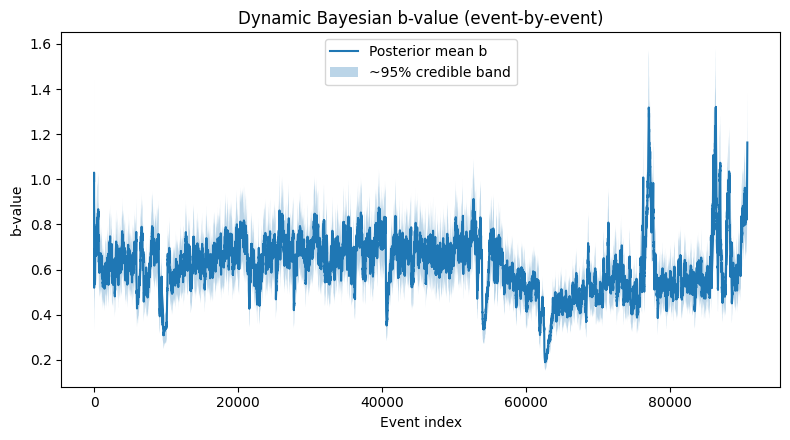

In [ ]:
updater = BayesianGRBUpdater(Mc=3, delta=0.99, a0=20, init_b_target=1, mag_key="mag", write_back=True)
results = updater.fit(seq)       # 逐事件更新；同时把结果字段写回0 seq
BayesianGRBUpdater.plot(seq)          # 绘图（可选传入 truth_lines / switch_index）

似然最大取值与Gamma分布期望的差异

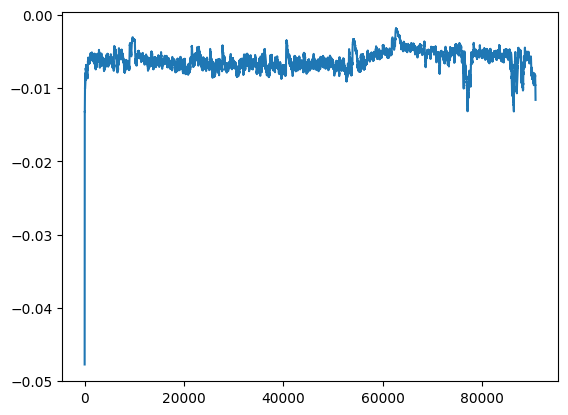

In [10]:
import math
import matplotlib.pyplot as plt
diff = (seq.a_t-1)/(math.log(10)*seq.s_t)-(seq.a_t)/(math.log(10)*seq.s_t)  
# diff.mean()
# diff.max()
plt.plot(diff)